# Computer Vision Nanodegree

## Project: Image Captioning

---

In this notebook, you will train your CNN-RNN model.  

You are welcome and encouraged to try out many different architectures and hyperparameters when searching for a good model.

This does have the potential to make the project quite messy!  Before submitting your project, make sure that you clean up:
- the code you write in this notebook.  The notebook should describe how to train a single CNN-RNN architecture, corresponding to your final choice of hyperparameters.  You should structure the notebook so that the reviewer can replicate your results by running the code in this notebook.  
- the output of the code cell in **Step 2**.  The output should show the output obtained when training the model from scratch.

This notebook **will be graded**.  

Feel free to use the links below to navigate the notebook:
- [Step 1](#step1): Training Setup
- [Step 2](#step2): Train your Model
- [Step 3](#step3): (Optional) Validate your Model

<a id='step1'></a>
## Step 1: Training Setup

In this step of the notebook, you will customize the training of your CNN-RNN model by specifying hyperparameters and setting other options that are important to the training procedure.  The values you set now will be used when training your model in **Step 2** below.

You should only amend blocks of code that are preceded by a `TODO` statement.  **Any code blocks that are not preceded by a `TODO` statement should not be modified**.

### Task #1

Begin by setting the following variables:
- `batch_size` - the batch size of each training batch.  It is the number of image-caption pairs used to amend the model weights in each training step. 
- `vocab_threshold` - the minimum word count threshold.  Note that a larger threshold will result in a smaller vocabulary, whereas a smaller threshold will include rarer words and result in a larger vocabulary.  
- `vocab_from_file` - a Boolean that decides whether to load the vocabulary from file. 
- `embed_size` - the dimensionality of the image and word embeddings.  
- `hidden_size` - the number of features in the hidden state of the RNN decoder.  
- `num_epochs` - the number of epochs to train the model.  We recommend that you set `num_epochs=3`, but feel free to increase or decrease this number as you wish.  [This paper](https://arxiv.org/pdf/1502.03044.pdf) trained a captioning model on a single state-of-the-art GPU for 3 days, but you'll soon see that you can get reasonable results in a matter of a few hours!  (_But of course, if you want your model to compete with current research, you will have to train for much longer._)
- `save_every` - determines how often to save the model weights.  We recommend that you set `save_every=1`, to save the model weights after each epoch.  This way, after the `i`th epoch, the encoder and decoder weights will be saved in the `models/` folder as `encoder-i.pkl` and `decoder-i.pkl`, respectively.
- `print_every` - determines how often to print the batch loss to the Jupyter notebook while training.  Note that you **will not** observe a monotonic decrease in the loss function while training - this is perfectly fine and completely expected!  You are encouraged to keep this at its default value of `100` to avoid clogging the notebook, but feel free to change it.
- `log_file` - the name of the text file containing - for every step - how the loss and perplexity evolved during training.

If you're not sure where to begin to set some of the values above, you can peruse [this paper](https://arxiv.org/pdf/1502.03044.pdf) and [this paper](https://arxiv.org/pdf/1411.4555.pdf) for useful guidance!  **To avoid spending too long on this notebook**, you are encouraged to consult these suggested research papers to obtain a strong initial guess for which hyperparameters are likely to work best.  Then, train a single model, and proceed to the next notebook (**3_Inference.ipynb**).  If you are unhappy with your performance, you can return to this notebook to tweak the hyperparameters (and/or the architecture in **model.py**) and re-train your model.

### Question 1

**Question:** Describe your CNN-RNN architecture in detail.  With this architecture in mind, how did you select the values of the variables in Task 1?  If you consulted a research paper detailing a successful implementation of an image captioning model, please provide the reference.

**Answer:** 


### (Optional) Task #2

Note that we have provided a recommended image transform `transform_train` for pre-processing the training images, but you are welcome (and encouraged!) to modify it as you wish.  When modifying this transform, keep in mind that:
- the images in the dataset have varying heights and widths, and 
- if using a pre-trained model, you must perform the corresponding appropriate normalization.

### Question 2

**Question:** How did you select the transform in `transform_train`?  If you left the transform at its provided value, why do you think that it is a good choice for your CNN architecture?

**Answer:** 

### Task #3

Next, you will specify a Python list containing the learnable parameters of the model.  For instance, if you decide to make all weights in the decoder trainable, but only want to train the weights in the embedding layer of the encoder, then you should set `params` to something like:
```
params = list(decoder.parameters()) + list(encoder.embed.parameters()) 
```

### Question 3

**Question:** How did you select the trainable parameters of your architecture?  Why do you think this is a good choice?

**Answer:** 

### Task #4

Finally, you will select an [optimizer](http://pytorch.org/docs/master/optim.html#torch.optim.Optimizer).

### Question 4

**Question:** How did you select the optimizer used to train your model?

**Answer:** 

In [3]:
cocoapi_loc = '/home/chris/workspace/datasets/coco'

In [4]:
import os
import glob


def delete_models():
    folder = "./models2"
    pkl_files = glob.glob(os.path.join(folder, "*.pkl"))
    for file in pkl_files:
        os.remove(file)
        print(f"Deleted: {file}")
    
delete_models()

In [5]:
from pycocotools.coco import COCO

def get_image_count(annFilePath):
    # Initialize COCO API
    coco = COCO(annFilePath)

    # Get all image IDs in the train2014 set
    image_ids = coco.getImgIds()

    # Get the total number of images
    num_images = len(image_ids)

    print(f"Number of images in {annFilePath.split('/')[-1]}: {num_images}")
    

In [6]:
get_image_count(cocoapi_loc + '/cocoapi/annotations/captions_train2014.json')

loading annotations into memory...
Done (t=0.19s)
creating index...
index created!
Number of images in captions_train2014.json: 82783


In [7]:
 get_image_count(cocoapi_loc + '/cocoapi/annotations/captions_val2014.json')

loading annotations into memory...
Done (t=0.10s)
creating index...
index created!
Number of images in captions_val2014.json: 40504


In [8]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
from torchvision import transforms
import sys
from pycocotools.coco import COCO
from data_loader import get_loader
from model import EncoderCNN, DecoderRNN
import math
import torch.optim as optim
import pickle

## Select appropriate values for the Python variables below.
batch_size = 256 #512 #256 #64          # batch size
vocab_threshold = 10      # minimum word count threshold
vocab_from_file = True   # if True, load existing vocab file
embed_size = 512 #512          # dimensionality of image and word embeddings
hidden_size = 768          # number of features in hidden state of the RNN decoder
num_layers = 1
num_epochs = 30             # number of training epochs
save_every = 1             # determines frequency of saving model weights
print_every = 1000          # determines window for printing average loss
log_file = 'models2/training_log.txt'       # name of file with saved training loss and perplexity
num_workers = 16
subset_size = 82000 #64000

network_parameters = {'vocab_threshold': vocab_threshold,
                      'embed_size': embed_size,
                      'hidden_size': hidden_size,
                      'num_layers': num_layers,
                      'subset_size': subset_size}

with open('models2/network_parameters.pkl', 'wb') as f:
    pickle.dump(network_parameters, f)

# Amend the image transform below.
transform_train = transforms.Compose([ 
    #transforms.Resize(256),   
    transforms.Resize(240), 
    #transforms.Resize((240,240)), 
    transforms.RandomCrop(224),                    
    transforms.RandomHorizontalFlip(p=0.3), 
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),                        
    transforms.Normalize((0.485, 0.456, 0.406),     
                         (0.229, 0.224, 0.225))])

# Build data loader
data_loader = get_loader(transform=transform_train,
                         mode='train',
                         batch_size=batch_size,
                         vocab_threshold=vocab_threshold,
                         vocab_from_file=vocab_from_file,
                         subset_size=subset_size,
                         cocoapi_loc=cocoapi_loc,
                         num_workers=num_workers)

# The size of the vocabulary.
vocab_size = len(data_loader.dataset.vocab)

# Initialize the encoder and decoder. 
encoder = EncoderCNN(embed_size)
decoder = DecoderRNN(embed_size, hidden_size, vocab_size, num_layers)

# Move models to GPU if CUDA is available. 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
encoder.to(device)
decoder.to(device)

# Define the loss function. 
criterion = nn.CrossEntropyLoss().cuda() if torch.cuda.is_available() else nn.CrossEntropyLoss()

# Specify the learnable parameters of the model.
#params = list(decoder.parameters()) + \
#         list(encoder.embed.parameters()) + \
#         list(encoder.batch_norm.parameters())

# Define the optimizer.
#optimizer = optim.Adam(params, lr=0.01)

# Learning rate for encoder and decoder
resnet_lr = 0.0001
encoder_lr = 0.001
decoder_lr = 0.001
attention_lr = 0.001

# Separate parameter groups with different learning rates
#optimizer = torch.optim.Adam([
#    {'params': encoder.resnet[7].parameters(), 'lr': encoder_lr, 'weight_decay': 1e-5},
#    {'params': encoder.embed.parameters(), 'lr': encoder_lr, 'weight_decay': 0.0},
#    {'params': encoder.batch_norm.parameters(), 'lr': encoder_lr, 'weight_decay': 0.0}, 
#    {'params': decoder.parameters(), 'lr': decoder_lr, 'weight_decay': 1e-5}
#])
#optimizer = torch.optim.Adam([
#    {'params': encoder.resnet[7].parameters(), 'lr': 0.0, 'weight_decay': 1e-5, 'name':'resnet'},
#    {'params': encoder.embed.parameters(), 'lr': encoder_lr, 'weight_decay': 0.0, 'name':'embed'},
#    {'params': encoder.batch_norm.parameters(), 'lr': encoder_lr, 'weight_decay': 0.0, 'name':'batch'}, 
#    {'params': decoder.parameters(), 'lr': decoder_lr, 'weight_decay': 1e-5, 'name':'decoder'}
#])
optimizer = torch.optim.Adam([
    {'params': encoder.resnet.parameters(), 'lr': 0.0, 'weight_decay': 1e-5, 'name': 'resnet'},
    {'params': encoder.embed.parameters(), 'lr': encoder_lr, 'weight_decay': 0.0, 'name': 'embed'},
    {'params': decoder.embed.parameters(), 'lr': decoder_lr, 'weight_decay': 0.0, 'name': 'embedding'},
    {'params': decoder.attention.parameters(), 'lr': decoder_lr, 'weight_decay': 1e-5, 'name': 'attention'},
    {'params': decoder.rnn.parameters(), 'lr': decoder_lr, 'weight_decay': 1e-5, 'name': 'rnn'},
    {'params': decoder.linear.parameters(), 'lr': decoder_lr, 'weight_decay': 1e-5, 'name': 'linear'}
])


# Set the total number of training steps per epoch.
total_step = math.ceil(len(data_loader.dataset.caption_lengths) / data_loader.batch_sampler.batch_size)
print(total_step)

Vocabulary successfully loaded from vocab.pkl file!
loading annotations into memory...
Done (t=0.17s)
creating index...
index created!
Obtaining caption lengths for the subset...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 82000/82000 [00:02<00:00, 32618.97it/s]


321


In [9]:
# Print the total number of keys in the word2idx dictionary.
print('Total number of tokens in vocabulary:', len(data_loader.dataset.vocab))

Total number of tokens in vocabulary: 6335


In [10]:
#for name, param in encoder.resnet.named_parameters():
#    if param.requires_grad:
#        print(name)

<a id='step2'></a>
## Step 2: Train your Model

Once you have executed the code cell in **Step 1**, the training procedure below should run without issue.  

It is completely fine to leave the code cell below as-is without modifications to train your model.  However, if you would like to modify the code used to train the model below, you must ensure that your changes are easily parsed by your reviewer.  In other words, make sure to provide appropriate comments to describe how your code works!  

You may find it useful to load saved weights to resume training.  In that case, note the names of the files containing the encoder and decoder weights that you'd like to load (`encoder_file` and `decoder_file`).  Then you can load the weights by using the lines below:

```python
# Load pre-trained weights before resuming training.
encoder.load_state_dict(torch.load(os.path.join('./models', encoder_file)))
decoder.load_state_dict(torch.load(os.path.join('./models', decoder_file)))
```

While trying out parameters, make sure to take extensive notes and record the settings that you used in your various training runs.  In particular, you don't want to encounter a situation where you've trained a model for several hours but can't remember what settings you used :).

### A Note on Tuning Hyperparameters

To figure out how well your model is doing, you can look at how the training loss and perplexity evolve during training - and for the purposes of this project, you are encouraged to amend the hyperparameters based on this information.  

However, this will not tell you if your model is overfitting to the training data, and, unfortunately, overfitting is a problem that is commonly encountered when training image captioning models.  

For this project, you need not worry about overfitting. **This project does not have strict requirements regarding the performance of your model**, and you just need to demonstrate that your model has learned **_something_** when you generate captions on the test data.  For now, we strongly encourage you to train your model for the suggested 3 epochs without worrying about performance; then, you should immediately transition to the next notebook in the sequence (**3_Inference.ipynb**) to see how your model performs on the test data.  If your model needs to be changed, you can come back to this notebook, amend hyperparameters (if necessary), and re-train the model.

That said, if you would like to go above and beyond in this project, you can read about some approaches to minimizing overfitting in section 4.3.1 of [this paper](http://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=7505636).  In the next (optional) step of this notebook, we provide some guidance for assessing the performance on the validation dataset.

In [8]:
encoder_file = '/home/chris/workspace/ComputerVisionND_P2_Image_Captioning_Project-25/models/encoder-042.pkl'
decoder_file = '/home/chris/workspace/ComputerVisionND_P2_Image_Captioning_Project-25/models/decoder-042.pkl'

encoder.load_state_dict(torch.load(encoder_file))
decoder.load_state_dict(torch.load(decoder_file))

# Move models to GPU if CUDA is available.
encoder.to(device)
decoder.to(device)

DecoderRNN(
  (embed): Embedding(9947, 512)
  (rnn): GRU(512, 512, batch_first=True)
  (linear): Linear(in_features=512, out_features=9947, bias=True)
  (drop1): Dropout(p=0.3, inplace=False)
  (drop2): Dropout(p=0.3, inplace=False)
)

In [33]:
def load_weights():
    # Specify the saved models to load.
    encoder_file = 'encoder-018.pkl'
    decoder_file = 'decoder-018.pkl'

    # Load the trained weights.
    encoder.load_state_dict(torch.load(os.path.join('./models', encoder_file)))
    decoder.load_state_dict(torch.load(os.path.join('./models', decoder_file)))

    # Move models to GPU if CUDA is available.
    encoder.to(device)
    decoder.to(device)
    
load_weights()

In [ ]:
import torch.utils.data as data
import numpy as np
import os
import requests
import time

from torch.optim.lr_scheduler import ReduceLROnPlateau

# Scheduler that reduces LR if val loss doesn't improve
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

# Open the training log file.
f = open(log_file, 'w')

accumulation_steps = 1  # Define how many steps to accumulate gradients
optimizer.zero_grad()   # Initialize gradients to zero

epoch_losses = []
best_val_loss = float('inf')
best_loss_so_far = float('inf')


freeze_epochs = 5


for epoch in range(1, num_epochs+1):

    epoch_loss = 0.0
    
    encoder.train()
    decoder.train()
    
    learning_rates = []
    for i, param_group in enumerate(optimizer.param_groups):
        lr = param_group['lr']
        if lr == 0.0:
            continue
        if len(learning_rates) == 0:
            learning_rates.append(lr)
        elif learning_rates[-1] != lr:
            learning_rates.append(lr)
        #print(f"Group {i} learning rate: {param_group['lr']}")
    #print("Learning rates: {}".format(learning_rates))    
        
    
    for i_step in range(1, total_step+1):

        # Randomly sample a caption length, and sample indices with that length.
        indices = data_loader.dataset.get_train_indices()
        new_sampler = data.sampler.SubsetRandomSampler(indices=indices)
        data_loader.batch_sampler.sampler = new_sampler
        

        # Obtain the batch.
        images, captions = next(iter(data_loader))

        # Move batch of images and captions to GPU if CUDA is available.
        images = images.to(device)
        captions = captions.to(device)

        # Pass the inputs through the CNN-RNN model.
        features = encoder(images)
        outputs = decoder(features, captions)

        # Calculate the batch loss.
        #loss = criterion(outputs.view(-1, vocab_size), captions.view(-1))
        loss = criterion(outputs.view(-1, vocab_size), captions[:, 1:].contiguous().view(-1))

        epoch_loss += loss.item()

        loss = loss / accumulation_steps  # Scale the loss by the accumulation steps

        # Backward pass.
        loss.backward()

        if i_step % accumulation_steps == 0 or i_step == total_step:
            # Update the parameters in the optimizer and zero the gradients.
            # torch.nn.utils.clip_grad_norm_(params, max_norm=5.0)
            all_params = []
            for group in optimizer.param_groups:
                all_params += group['params']
            torch.nn.utils.clip_grad_norm_(all_params, max_norm=5.0)
            optimizer.step()
            optimizer.zero_grad()

        # Get training statistics.
        #stats = 'Epoch [%d/%d], Step [%d/%d], Loss: %.3f, Perplexity: %5.3f, Lr: %s' % (
        #    epoch, num_epochs,
        #    i_step, total_step,
        #    loss.item() * accumulation_steps,
        #    np.exp(loss.item() * accumulation_steps),
        #    str(learning_rates)
        #)
        stats = 'Epoch [%d/%d], Step [%d/%d], Loss: %.3f, Perplexity: %5.3f, Lr: [%s]' % (
            epoch, num_epochs,
            i_step, total_step,
            loss.item() * accumulation_steps,
            np.exp(loss.item() * accumulation_steps),
            ", ".join(f"{lr}" for lr in learning_rates)
        )

        # Print training statistics (on same line).
        print('\r' + stats + ' ' * 10, end="")
        sys.stdout.flush()

        # Print training statistics to file.
        f.write(stats + '\n')
        f.flush()


        # Print training statistics (on different line).
        if i_step % print_every == 0:
            print('\r' + stats)


    # Save the weights.
    if epoch % save_every == 0:
        torch.save(decoder.state_dict(), os.path.join('./models2', 'decoder-%03d.pkl' % epoch))
        torch.save(encoder.state_dict(), os.path.join('./models2', 'encoder-%03d.pkl' % epoch))
        
    


    epoch_loss /= total_step
    epoch_losses.append(epoch_loss)
    scheduler.step(epoch_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    
    
    print(' ')
    #print(f"Epoch loss: {epoch_loss:.3f}, Learn rate: {current_lr}")
    print(f"Epoch loss: {epoch_loss:.5f}")
    
    # Save best model based on validation loss
    if epoch_loss < best_loss_so_far:
        best_loss_so_far = epoch_loss
        #torch.save(decoder.state_dict(), os.path.join('./models', 'decoder-%d.pkl' % epoch))
        #torch.save(encoder.state_dict(), os.path.join('./models', 'encoder-%d.pkl' % epoch))
        torch.save(decoder.state_dict(), os.path.join('./models2', 'decoder-best.pkl'))
        torch.save(encoder.state_dict(), os.path.join('./models2', 'encoder-best.pkl'))
        print(f"✔️ New best epoch loss: [{best_loss_so_far:.5f}] — model saved.")
    
    lr_min = 1e-5
    #if current_lr < lr_min:
    if min(learning_rates) < lr_min:
        print(f"Early stopping because lr < {lr_min}")
        print('Finished Training')
        break
        
    if epoch == freeze_epochs:
        print(f"Unfreezing ResNet after epoch {epoch}.")
        for param_group in optimizer.param_groups:
            if param_group.get('name') == 'resnet':
                param_group['lr'] = resnet_lr


# Close the training log file.
f.close()

Epoch [1/30], Step [73/321], Loss: 4.113, Perplexity: 61.104, Lr: [0.001]           

Min epoch loss: 0.38103233743458986


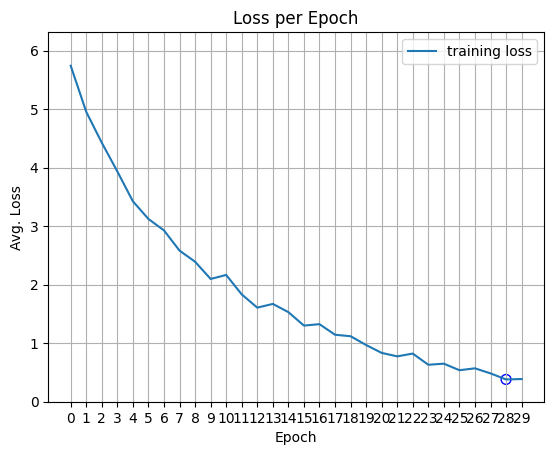

In [12]:
import matplotlib.pyplot as plt

min_epoch_idx = epoch_losses.index(min(epoch_losses))
min_epoch_val = epoch_losses[min_epoch_idx]

# Plot the losses
plt.plot(epoch_losses, label="training loss")

plt.xlabel("Epoch")
plt.ylabel("Avg. Loss")
plt.title("Loss per Epoch")
plt.grid(True)
plt.ylim(0, max(epoch_losses) * 1.1)
plt.legend()

plt.scatter(min_epoch_idx, min_epoch_val, facecolors='none', edgecolors='blue', s=50, label='min train loss')
plt.xticks(range(0,len(epoch_losses)))

print("Min epoch loss:", min_epoch_val)

<a id='step3'></a>
## Step 3: (Optional) Validate your Model

To assess potential overfitting, one approach is to assess performance on a validation set.  If you decide to do this **optional** task, you are required to first complete all of the steps in the next notebook in the sequence (**3_Inference.ipynb**); as part of that notebook, you will write and test code (specifically, the `sample` method in the `DecoderRNN` class) that uses your RNN decoder to generate captions.  That code will prove incredibly useful here. 

If you decide to validate your model, please do not edit the data loader in **data_loader.py**.  Instead, create a new file named **data_loader_val.py** containing the code for obtaining the data loader for the validation data.  You can access:
- the validation images at filepath `'/opt/cocoapi/images/train2014/'`, and
- the validation image caption annotation file at filepath `'/opt/cocoapi/annotations/captions_val2014.json'`.

The suggested approach to validating your model involves creating a json file such as [this one](https://github.com/cocodataset/cocoapi/blob/master/results/captions_val2014_fakecap_results.json) containing your model's predicted captions for the validation images.  Then, you can write your own script or use one that you [find online](https://github.com/tylin/coco-caption) to calculate the BLEU score of your model.  You can read more about the BLEU score, along with other evaluation metrics (such as TEOR and Cider) in section 4.1 of [this paper](https://arxiv.org/pdf/1411.4555.pdf).  For more information about how to use the annotation file, check out the [website](http://cocodataset.org/#download) for the COCO dataset.

### Create Data Loader for Validation Data

In [1]:
cocoapi_loc = '/home/chris/workspace/datasets/coco'

In [2]:
%load_ext autoreload
%autoreload 2

import pickle
import torch
import torch.nn as nn
import math
from torchvision import transforms

from my_data_loader import get_my_loader  

with open('models2/network_parameters.pkl', 'rb') as f:
    loaded_params = pickle.load(f)

batch_size = 512
vocab_threshold = loaded_params['vocab_threshold']
vocab_from_file = True  
#print('vocab', vocab_threshold)

num_workers = 16
subset_size = 1000 #4000

# Amend the image transform below.
transform_val = transforms.Compose([ 
    #transforms.Resize(230),
    transforms.Resize((240,240)),   
    transforms.RandomCrop(224),
    #transforms.RandomHorizontalFlip(p=0.3), 
    #transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05),
    transforms.ToTensor(),                         
    transforms.Normalize((0.485, 0.456, 0.406),      
                         (0.229, 0.224, 0.225))])

# Build data loader (TODO: You can change the subset_size, however a 
# very large value would increase training time considerably)
data_loader_val = get_my_loader(transform=transform_val,
                         mode='val',
                         batch_size=batch_size,
                         vocab_threshold=vocab_threshold,
                         vocab_from_file=vocab_from_file,
                         subset_size=subset_size,
                         cocoapi_loc=cocoapi_loc,
                         num_workers=num_workers)

total_steps_val = math.ceil(len(data_loader_val.dataset.caption_lengths) / data_loader_val.batch_sampler.batch_size)
print(total_steps_val)

Vocabulary successfully loaded from vocab.pkl file!
loading annotations into memory...
Done (t=0.08s)
creating index...
index created!
Obtaining caption lengths for the subset...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 28922.25it/s]

2


In [3]:
import sys
import torch.utils.data as data

def get_predicted_captions(encoder, decoder):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    encoder.eval()
    decoder.eval()

    # Store predictions
    decoded_captions = []
    predicted_captions = []

    # Evaluation loop
    with torch.no_grad():

        for j_step in range(1, total_steps_val+1):

            stats = 'Step {}/{}'.format(j_step, total_steps_val)
            print('\r' + stats, end="")
            sys.stdout.flush()

            indices_val = data_loader_val.dataset.get_val_indices()
            new_sampler_val = data.sampler.SubsetRandomSampler(indices=indices_val)
            data_loader_val.batch_sampler.sampler = new_sampler_val

            # Obtain the batch.
            images, captions, img_ids, ann_ids = next(iter(data_loader_val))

            images = images.to(device)
            features = encoder(images)
            
            
            sampled_ids_batch = decoder.sample(features)  # shape: (B, max_len)

            encoded_captions = []
            for i in range(features.size(0)):
                sampled_ids = sampled_ids_batch[i]  # shape: (max_len,)
                img_id = img_ids[i]
                ann_id = ann_ids[i]
                encoded_captions.append({'image_id': img_id, 'ann_id': ann_id, 'word_ids': sampled_ids})


            # Convert word IDs to words
            #decoded_captions = []
            #predicted_captions = []
            for entry in encoded_captions:
                img_id = entry['image_id']
                ann_id = entry['ann_id']
                word_ids = entry['word_ids']

                #decoded_caption = clean_sentence(word_ids)
                decoded_caption = []
                for word_id in word_ids:
                    #word = data_loader_val.dataset.vocab.idx2word[word_id]
                    #print(word_id.shape)
                    word = data_loader_val.dataset.vocab.idx2word[word_id.item()]
                    if word == '<end>':
                        break
                    if word != '<start>':
                        decoded_caption.append(word)
                decoded_captions.append(decoded_caption)

                caption = ''
                for i, word in enumerate(decoded_caption):
                    if word in ['.', ',', '!', '?', ':', ';', "'"]:
                        caption = caption.rstrip() + word  # attach punctuation without space
                    else:
                        caption += ' ' + word if caption else word.capitalize()  # first word: no space

                predicted_captions.append({'image_id': img_id, 'ann_id': ann_id, 'caption': caption})
    
    print(' ')          
    return predicted_captions, decoded_captions

#print(len(predicted_captions))

In [4]:
import sys
import os
import contextlib

@contextlib.contextmanager
def suppress_stdout():
    with open(os.devnull, 'w') as devnull:
        old_stdout = sys.stdout
        sys.stdout = devnull
        try:
            yield
        finally:
            sys.stdout = old_stdout


In [5]:
from pycocotools.coco import COCO
def generate_references(predictions):
    with suppress_stdout():
        coco_val = COCO(cocoapi_loc + '/cocoapi/annotations/captions_val2014.json')
    references = []
    for pred in predictions:
        image_id = pred['image_id']
        #print(image_id)
        ann_ids = coco_val.getAnnIds(imgIds=image_id)  # Step 2: get all annotation IDs for that image
        #print(ann_ids)
        annotations = coco_val.loadAnns(ann_ids)       # Step 3: load all captions
        captions = [ann['caption'] for ann in annotations]
        #print(captions)
        references.append({'image_id': image_id, 'captions': captions})
    return references

In [6]:
import json
from pycocotools.coco import COCO
from pycocoevalcap.eval import COCOEvalCap
from pycocoevalcap.bleu.bleu import Bleu
from pycocoevalcap.meteor.meteor import Meteor
from pycocoevalcap.rouge.rouge import Rouge
from pycocoevalcap.cider.cider import Cider

def get_metrics(references, hypotheses):
    # Prepare data
    gts = {ref['image_id']: ref['captions'] for ref in references}
    res = {hyp['image_id']: [hyp['caption']] for hyp in hypotheses}

    # Build COCO-style ground truth
    def build_coco_annotations(gts):
        annotations, images = [], []
        ann_id = 0
        for image_id, captions in gts.items():
            images.append({'id': image_id})
            for caption in captions:
                annotations.append({
                    'image_id': image_id,
                    'id': ann_id,
                    'caption': caption
                })
                ann_id += 1
        return {
            'annotations': annotations,
            'images': images,
            'type': 'captions',
            'info': {},
            'licenses': []
        }

    # Save ground truth and results
    with open("gts.json", "w") as f:
        json.dump(build_coco_annotations(gts), f)

    with open("res.json", "w") as f:
        json.dump(
            [{'image_id': k, 'caption': v[0]} for k, v in res.items()],
            f
        )

    # Load data using COCO tools
    with suppress_stdout():
        coco = COCO("gts.json")
        coco_res = coco.loadRes("res.json")


    # Convert to required dict format: {image_id: [captions]}
    gts_dict = {img_id: [ann["caption"] for ann in coco.imgToAnns[img_id]] for img_id in coco.getImgIds()}
    res_dict = {ann["image_id"]: [ann["caption"]] for ann in coco_res.dataset["annotations"]}

    # Evaluate using metrics
    scorers = [
        (Bleu(4), ["Bleu_1", "Bleu_2", "Bleu_3", "Bleu_4"]),
    #    (Meteor(), "METEOR"),
        (Rouge(), "ROUGE_L"),
        (Cider(), "CIDEr")
    ]

    # Compute and print scores
    eval_scores = {}
    for scorer, method in scorers:
        #print(f"Computing {method}...")
        with suppress_stdout():
            score, _ = scorer.compute_score(gts_dict, res_dict)
        if isinstance(method, list):
            for m, sc in zip(method, score):
                eval_scores[m] = sc
        else:
            eval_scores[method] = score

    # Output results
    for metric, score in eval_scores.items():
        if metric == "CIDEr":
            print(f"{metric}: {score:.4f}")
        
    return eval_scores

In [7]:
import os
import torch
from model import EncoderCNN, DecoderRNN
import pickle

def calculate_metrics(encoder_file, decoder_file, data_loader):
    
    with open('models2/network_parameters.pkl', 'rb') as f:
        loaded_params = pickle.load(f)

    embed_size = loaded_params['embed_size']
    hidden_size = loaded_params['hidden_size']
    num_layers = loaded_params['num_layers']

    # The size of the vocabulary.
    vocab_size = len(data_loader.dataset.vocab)

    # Initialize the encoder and decoder, and set each to inference mode.
    encoder = EncoderCNN(embed_size)
    decoder = DecoderRNN(embed_size, hidden_size, vocab_size, num_layers)
    encoder.eval()
    decoder.eval()

    # Load the trained weights.
    #encoder.load_state_dict(torch.load(os.path.join('./models', encoder_file)))
    #decoder.load_state_dict(torch.load(os.path.join('./models', decoder_file)))
    print('loading', encoder_file)
    print('loading', decoder_file)
    encoder.load_state_dict(torch.load(encoder_file))
    decoder.load_state_dict(torch.load(decoder_file))

    # Move models to GPU if CUDA is available.
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    encoder.to(device)
    decoder.to(device)
    
    
    predicted_captions, decoded_captions = get_predicted_captions(encoder, decoder)
    
    #print('\nprediction')
    #print(predicted_captions[:2])
    
    
    # Preapare data for metric calculation
    hypotheses = predicted_captions
    references = generate_references(hypotheses)
    #print('\nreferences')
    #print(references[:2])
    #print(len(references))
    
    eval_scores = get_metrics(references, hypotheses)
    
    return eval_scores

In [8]:
import os
import glob


def get_models():
    folder = "./models2"
    pkl_files = glob.glob(os.path.join(folder, "*.pkl"))
    encoders = []
    decoders = []
    for file in sorted(pkl_files):
        if file.find('best') != -1:
            continue
        elif file.find('encoder') != -1:
            encoders.append(file)
        elif file.find('decoder') != -1:
            decoders.append(file)
    
    return encoders, decoders
       
encoders, decoders = get_models()

In [9]:
total_scores = []
for encoder_file, decoder_file in zip(encoders, decoders):
    eval_scores = calculate_metrics(encoder_file, decoder_file, data_loader_val)
    total_scores.append([encoder_file, decoder_file, eval_scores])
    print(' ')
print('done')

with open('models/validation_scores.pkl', 'wb') as f:
    pickle.dump(total_scores, f) 

loading ./models/encoder-001.pkl
loading ./models/decoder-001.pkl
Step 2/2 
CIDEr: 0.0009
 
loading ./models/encoder-002.pkl
loading ./models/decoder-002.pkl
Step 2/2 
CIDEr: 0.0053
 
loading ./models/encoder-003.pkl
loading ./models/decoder-003.pkl
Step 2/2 
CIDEr: 0.0535
 
loading ./models/encoder-004.pkl
loading ./models/decoder-004.pkl
Step 2/2 
CIDEr: 0.1043
 
loading ./models/encoder-005.pkl
loading ./models/decoder-005.pkl
Step 2/2 
CIDEr: 0.2829
 
loading ./models/encoder-006.pkl
loading ./models/decoder-006.pkl
Step 2/2 
CIDEr: 0.3786
 
loading ./models/encoder-007.pkl
loading ./models/decoder-007.pkl
Step 2/2 
CIDEr: 0.4254
 
loading ./models/encoder-008.pkl
loading ./models/decoder-008.pkl
Step 2/2 
CIDEr: 0.4153
 
loading ./models/encoder-009.pkl
loading ./models/decoder-009.pkl
Step 2/2 
CIDEr: 0.4225
 
loading ./models/encoder-010.pkl
loading ./models/decoder-010.pkl
Step 2/2 
CIDEr: 0.4660
 
loading ./models/encoder-011.pkl
loading ./models/decoder-011.pkl
Step 2/2 
CIDE

In [10]:
def get_scores(total_scores):
    bleu_vals = []
    rougel_vals = []
    cider_vals = []
    for scores in total_scores:
        bleu = [0,0,0,0]
        for metric, score in scores[2].items():
            if metric == "Bleu_1":
                bleu[0] = score
            elif metric == "Bleu_2":
                bleu[1] = score
            elif metric == "Bleu_3":
                bleu[2] = score
            elif metric == "Bleu_4":
                bleu[3] = score
            elif metric == "ROUGE_L":
                rougel_vals.append(score)
            elif metric == "CIDEr":
                cider_vals.append(score)

        bleu_vals.append(bleu)
    return bleu_vals, rougel_vals, cider_vals

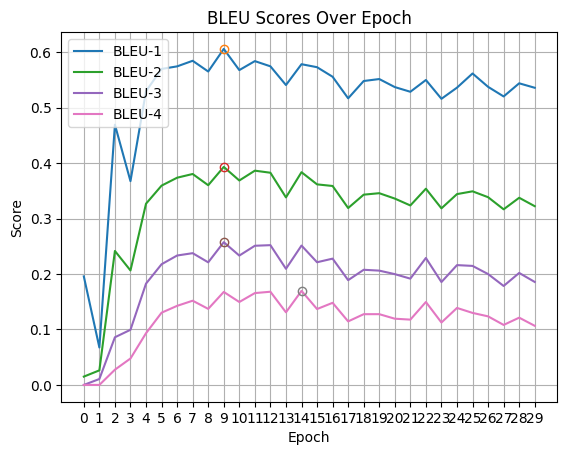

Max. BLEU-1 value 0.60569 in Epoch 10.
Max. BLEU-2 value 0.39298 in Epoch 10.
Max. BLEU-3 value 0.25730 in Epoch 10.
Max. BLEU-4 value 0.16951 in Epoch 15.


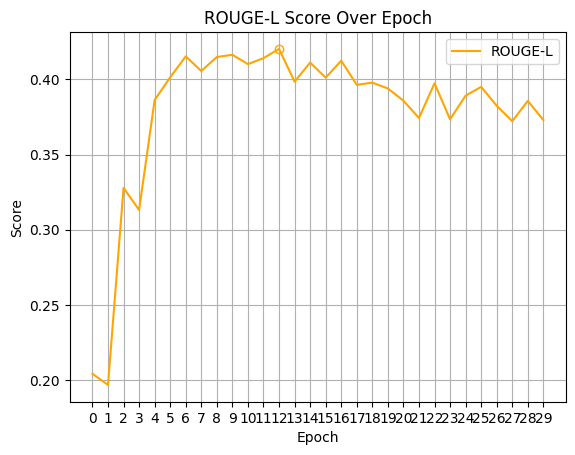

Max. ROUGE-L value 0.42032 in Epoch 13.


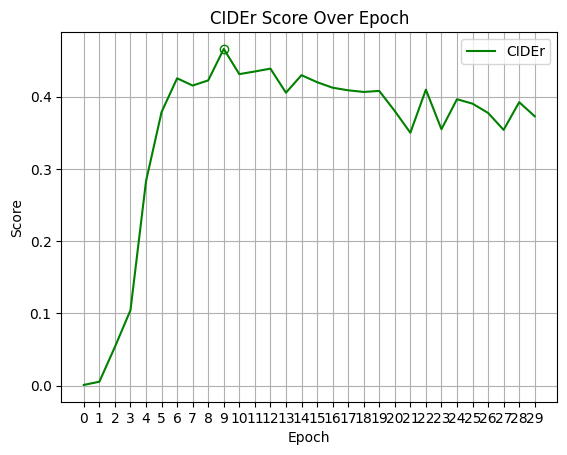

Max. CIDEr value 0.46604 in Epoch 10.


In [11]:
import matplotlib.pyplot as plt

bleu_vals, rougel_vals, cider_vals = get_scores(total_scores)

# Unpack BLEU scores
bleu_1 = [b[0] for b in bleu_vals]
bleu_2 = [b[1] for b in bleu_vals]
bleu_3 = [b[2] for b in bleu_vals]
bleu_4 = [b[3] for b in bleu_vals]

# Plot BLEU scores
max_bleu_idx = []
plt.figure()
for bleu, label in zip([bleu_1, bleu_2, bleu_3, bleu_4], ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4']):
    plt.plot(bleu, label=label)
    max_idx = bleu.index(max(bleu))
    max_bleu_idx.append(max_idx)
    plt.plot(max_idx, bleu[max_idx], 'o', markerfacecolor='none')  # unfilled circle

plt.title('BLEU Scores Over Epoch')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.xticks(range(0,len(bleu_vals)))
plt.show()
print('Max. BLEU-1 value {:.5f} in Epoch {}.'.format(bleu_1[max_bleu_idx[0]], max_bleu_idx[0]+1))
print('Max. BLEU-2 value {:.5f} in Epoch {}.'.format(bleu_2[max_bleu_idx[1]], max_bleu_idx[1]+1))
print('Max. BLEU-3 value {:.5f} in Epoch {}.'.format(bleu_3[max_bleu_idx[2]], max_bleu_idx[2]+1))
print('Max. BLEU-4 value {:.5f} in Epoch {}.'.format(bleu_4[max_bleu_idx[3]], max_bleu_idx[3]+1))

# Plot ROUGE-L
plt.figure()
plt.plot(rougel_vals, label='ROUGE-L', color='orange')
max_idx = rougel_vals.index(max(rougel_vals))
plt.plot(max_idx, rougel_vals[max_idx], 'o', color='orange', markerfacecolor='none')
plt.title('ROUGE-L Score Over Epoch')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.grid(True)
plt.legend()
plt.xticks(range(0,len(bleu_vals)))
plt.show()
print('Max. ROUGE-L value {:.5f} in Epoch {}.'.format(rougel_vals[max_idx], max_idx+1))

# Plot CIDEr
plt.figure()
plt.plot(cider_vals, label='CIDEr', color='green')
max_idx = cider_vals.index(max(cider_vals))
plt.plot(max_idx, cider_vals[max_idx], 'o', color='green', markerfacecolor='none')
plt.title('CIDEr Score Over Epoch')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.grid(True)
plt.legend()
plt.xticks(range(0,len(bleu_vals)))
plt.show()

print('Max. CIDEr value {:.5f} in Epoch {}.'.format(cider_vals[max_idx], max_idx+1))


### Generate Captions for Validation Data Subset

In [22]:
from PIL import Image
from IPython.display import display
import os
    
def plot_image(image_id):
    image_info = coco.loadImgs(image_id)[0]
    #print('image_info:')
    print(image_info)
    
    ann_ids = coco.getAnnIds(imgIds=image_id) 
    annotations = coco.loadAnns(ann_ids)      
    captions = [ann['caption'] for ann in annotations]
    #print('captions:')
    print(' ')
    print(captions)

    img_folder = cocoapi_loc + '/cocoapi/images/val2014/'
    img_path = os.path.join(img_folder, image_info['file_name'])

    img = Image.open(img_path)
    display(img)